<a href="https://colab.research.google.com/github/sauraviitj/neural-networks-zero-to-hero/blob/main/1%20and%202%20Micrograd/micrograd_lecture_one_second_half.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x + 5

In [ ]:
f(3.0)

20.0

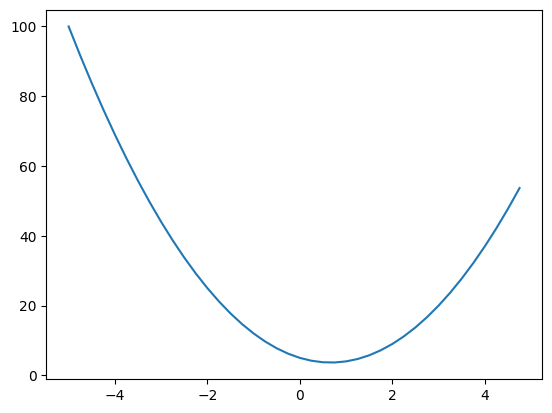

In [ ]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
h = 0.000001
x = 2/3
(f(x + h) - f(x))/h

2.999378523327323e-06

In [ ]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [ ]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)


d1 4.0
d2 4.0001
slope 0.9999999999976694


## New Features Added To Value Class

### Automatic conversion of numbers

Allows:

```python
a + 2
a * 3
```

by converting numbers into:

```python
Value(2)
Value(3)
```

---

### Power

```python
a ** n
```

Derivative:

$$
\frac{d(a^n)}{da}
=
n a^{n-1}
$$

---

### Reverse operators

```python
2 + a
2 * a
```

supported using:

```python
__radd__()
__rmul__()
```

---

### Negation

```python
-a
```

implemented as:

```python
a * (-1)
```

---

### Subtraction

```python
a - b
```

implemented as:

```python
a + (-b)
```

---

### Division

```python
a / b
```

implemented as:

```python
a * b**(-1)
```

---

### Exponential

```python
x.exp()
```

Computes:

$$
e^x
$$

Derivative:

$$
\frac{d(e^x)}{dx}
=
e^x
$$

Implemented as:

```python
self.grad += out.data * out.grad
```

because:

```python
out.data = e^x
```

---

Goal:

Make Value behave like a normal Python number while retaining automatic differentiation.

In [ ]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward

    return out


  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()



In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


In [ ]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

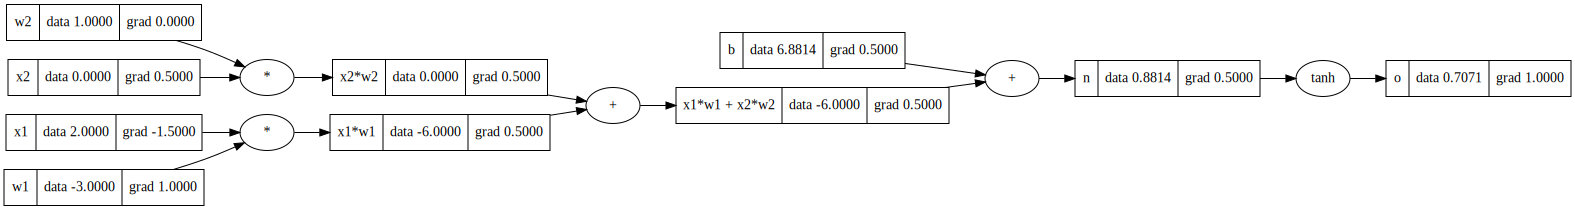

In [ ]:
draw_dot(o)

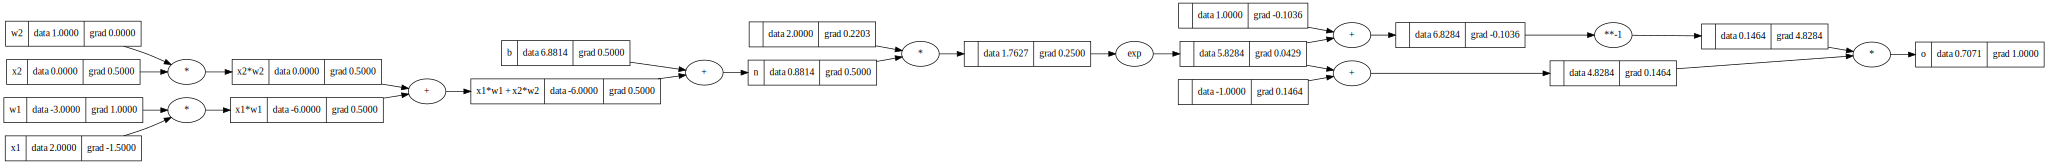

In [ ]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

##Pytorch

In [ ]:
import torch

In [ ]:
x=torch.Tensor([[1,2,3],[4,5,6]]) # declaring a 2*3 tensor
x

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [ ]:
x.shape

torch.Size([2, 3])

In [ ]:
x1 = torch.Tensor([2.0]).double()                # Input feature x1 = 2.0
x1.requires_grad = True                          # Tell PyTorch to track gradients for x1

x2 = torch.Tensor([0.0]).double()  ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()   ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()    ;w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b                            # Neuron pre-activation: n = x1*w1 + x2*w2 + b

o = torch.tanh(n)                                # Apply tanh activation: o = tanh(n)

print(o.data)                             # Print output value (extract scalar from tensor) we can add o.data.item() or o.item() to get just the value

o.backward()                                     # Compute all gradients d(o)/d(variable) using backpropagation

print('---')

print('x2', x2.grad.item())                      # x2.grad = do/dx2
print('w2', w2.grad.item())                      # w2.grad = do/dw2
print('x1', x1.grad.item())                      # x1.grad = do/dx1
print('w1', w1.grad.item())                      # w1.grad = do/dw1

tensor([0.7071], dtype=torch.float64)
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


##Build a neurel network from scratch

```
Value
  ↓
Neuron
  ↓
Layer
  ↓
MLP (Multi Layer Perceptron)
```

In [ ]:
import random




# ─────────────────────────────────────────────
# NEURON — the smallest unit
# One brain cell. Takes multiple inputs,
# multiplies each by a weight, adds bias, squashes with tanh.
# ─────────────────────────────────────────────

class Neuron:

  def __init__(self, nin):
    # nin = how many inputs this neuron receives
    # One weight per input — randomly initialised between -1 and 1
    # These are what the network LEARNS during training
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    # One bias — the neuron's default value before seeing any input
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    # zip pairs each weight with its input: (w[0],x[0]), (w[1],x[1])...
    # multiply each pair, sum them all, start the sum from self.b (adds bias)
    # result: w[0]*x[0] + w[1]*x[1] + ... + bias
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    # tanh squashes output to between -1 and +1
    # prevents numbers exploding as layers stack
    # also adds non-linearity — critical for the network to learn complex patterns
    out = act.tanh()
    return out

  def parameters(self):
    # all learnable values in this neuron = weights + bias
    # training loop uses this to know what to update
    return self.w + [self.b]


# ─────────────────────────────────────────────
# LAYER — a row of neurons side by side
# All neurons receive the SAME input
# but each has its own weights — so each learns something different
# ─────────────────────────────────────────────

class Layer:

  def __init__(self, nin, nout):
    # nin  = inputs coming in
    # nout = how many neurons in this layer
    # creates nout neurons, each expecting nin inputs
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    # run every neuron on the same input x
    # each neuron produces one output value
    outs = [n(x) for n in self.neurons]
    # if only 1 neuron return the value directly, not wrapped in a list
    # if multiple neurons return the full list
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    # collect parameters from ALL neurons in this layer into one flat list
    # nested loop in one line: for each neuron → get its parameters
    return [p for neuron in self.neurons for p in neuron.parameters()]


# ─────────────────────────────────────────────
# MLP — Multi Layer Perceptron — the full network
# Multiple layers stacked in sequence
# Output of one layer becomes input of the next
# ─────────────────────────────────────────────

class MLP:

  def __init__(self, nin, nouts):
    # nin   = inputs to the whole network
    # nouts = list of layer sizes e.g. [4, 4, 1]
    #
    # MLP(3, [4, 4, 1]) means:
    #   3 inputs → Layer of 4 → Layer of 4 → Layer of 1 (output)
    # build full size list: [nin, layer1, layer2, ..., output]
    sz = [nin] + nouts  # for n= MLP(3,[4,4,1]) nin =3 and nouts= 4,4,1, so s[z]=[3,4,4,1]
    # pair consecutive sizes to define each layer
    # Layer 0: 3 inputs  → 4 outputs
    # Layer 1: 4 inputs  → 4 outputs
    # Layer 2: 4 inputs  → 1 output
    # each layer's output = next layer's input — this is how they connect
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]  # len(outs))= 3, so range is 0,1,2. therefore it creates layer(3,4), layer (4,4), (4,1)

  def __call__(self, x): # performs the forward pass of the entire neural network.
    # forward pass — input flows through every layer in sequence
    # output of each layer becomes input to the next
    for layer in self.layers:
      x = layer(x)
    # after all layers, x is the final network output
    return x

  def parameters(self):
    # collect ALL parameters from ALL layers into one flat list
    # this is what the training loop iterates over to update weights
    return [p for layer in self.layers for p in layer.parameters()]


```
Input Layer        Hidden Layer 1      Hidden Layer 2      Output Layer

x1 ───────┐
x2 ───────┼────► ○ ○ ○ ○ ─────► ○ ○ ○ ○ ─────► ○
x3 ───────┘
```

 the neural network bottom-up:

1. Value
   - stores data and gradients
   - supports automatic differentiation

2. Neuron
   - computes:
     tanh(w1*x1 + w2*x2 + ... + b)

3. Layer
   - collection of neurons
   - returns outputs from all neurons

4. MLP (Multi Layer Perceptron)
   - collection of layers
   - forms the complete neural network

Hierarchy:

MLP
 └── Layers
      └── Neurons
           └── Weights & Biases (Values)

Layer(3,4)   # shape 3 → 4 input to hidden layer 1
Layer(4,4)   # shape 4 → 4 hidden layer 1 to hidden layer 2
Layer(4,1)   # shape 4 → 1 hidden layer 2 to output layer

In [ ]:
x = [2.0, 3.0, -1.0] #test data
n = MLP(3, [4, 4, 1])
n(x)  # n(X) is Output of the neural network for input x

Value(data=-0.17965961376397907)

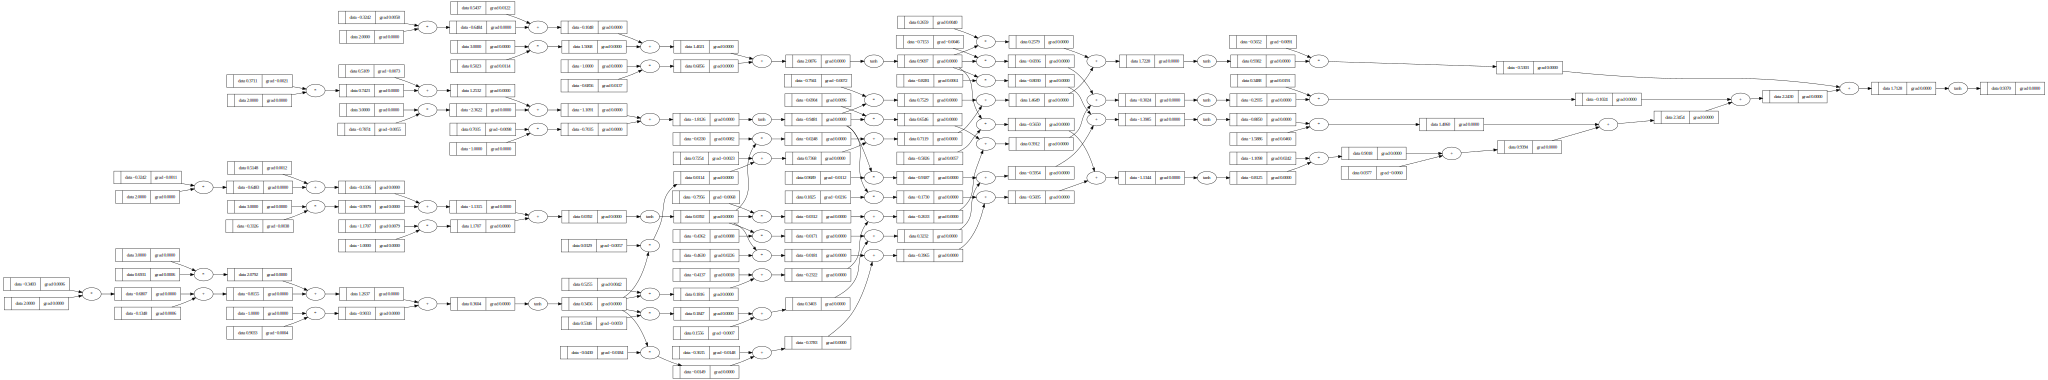

In [ ]:
draw_dot(n(x))

This is the training dataset for the neural network.

```
Input                     Desired Output

[2, 3, -1]              →   1

[3, -1, 0.5]            →  -1

[0.5, 1, 1]             →  -1

[1, 1, -1]              →   1

```

In [ ]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [ ]:
for k in range(20):

  # Forward pass:
  # Run the network on all training examples
  # to get predictions.
  ypred = [n(x) for x in xs]

  # Loss:
  # Sum of squared errors between
  # predicted and actual outputs.
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # Clear old gradients.
  for p in n.parameters():
    p.grad = 0.0

  # Backpropagation:
  # Compute d(loss)/d(parameter)
  # for every weight and bias.
  loss.backward()

  # Gradient descent:
  # Move parameters in direction
  # that reduces the loss.
  for p in n.parameters(): #n.parameters traverses the entire neural network. check def parameters in class Neuron
    p.data += -0.1 * p.grad

  # Print iteration number and loss.
  print(k, loss.data)

0 7.868974431264329
1 4.837465706719346
2 5.1862851660013405
3 3.560114257775009
4 1.9847214111851614
5 0.9826845890594743
6 0.8061747414317708
7 0.0493671069731526
8 0.03553480961322768
9 0.028530516283944735
10 0.024181558169827568
11 0.021182203835690906
12 0.018972199306442672
13 0.017266948336794274
14 0.015905303208630775
15 0.014788743210440844
16 0.013853473116951507
17 0.01305628791661225
18 0.012366850952392478
19 0.011763217091433263


In [ ]:
n.layers[0].neurons[0].w[0].data

-0.10771602384457062

In [ ]:
n.layers[0].neurons[0].w[0].grad

0.004178957899192102

In [ ]:
ypred

[Value(data=0.9516868784588493),
 Value(data=-0.9824715177436527),
 Value(data=-0.9506277428793887),
 Value(data=0.9589539927969639)]

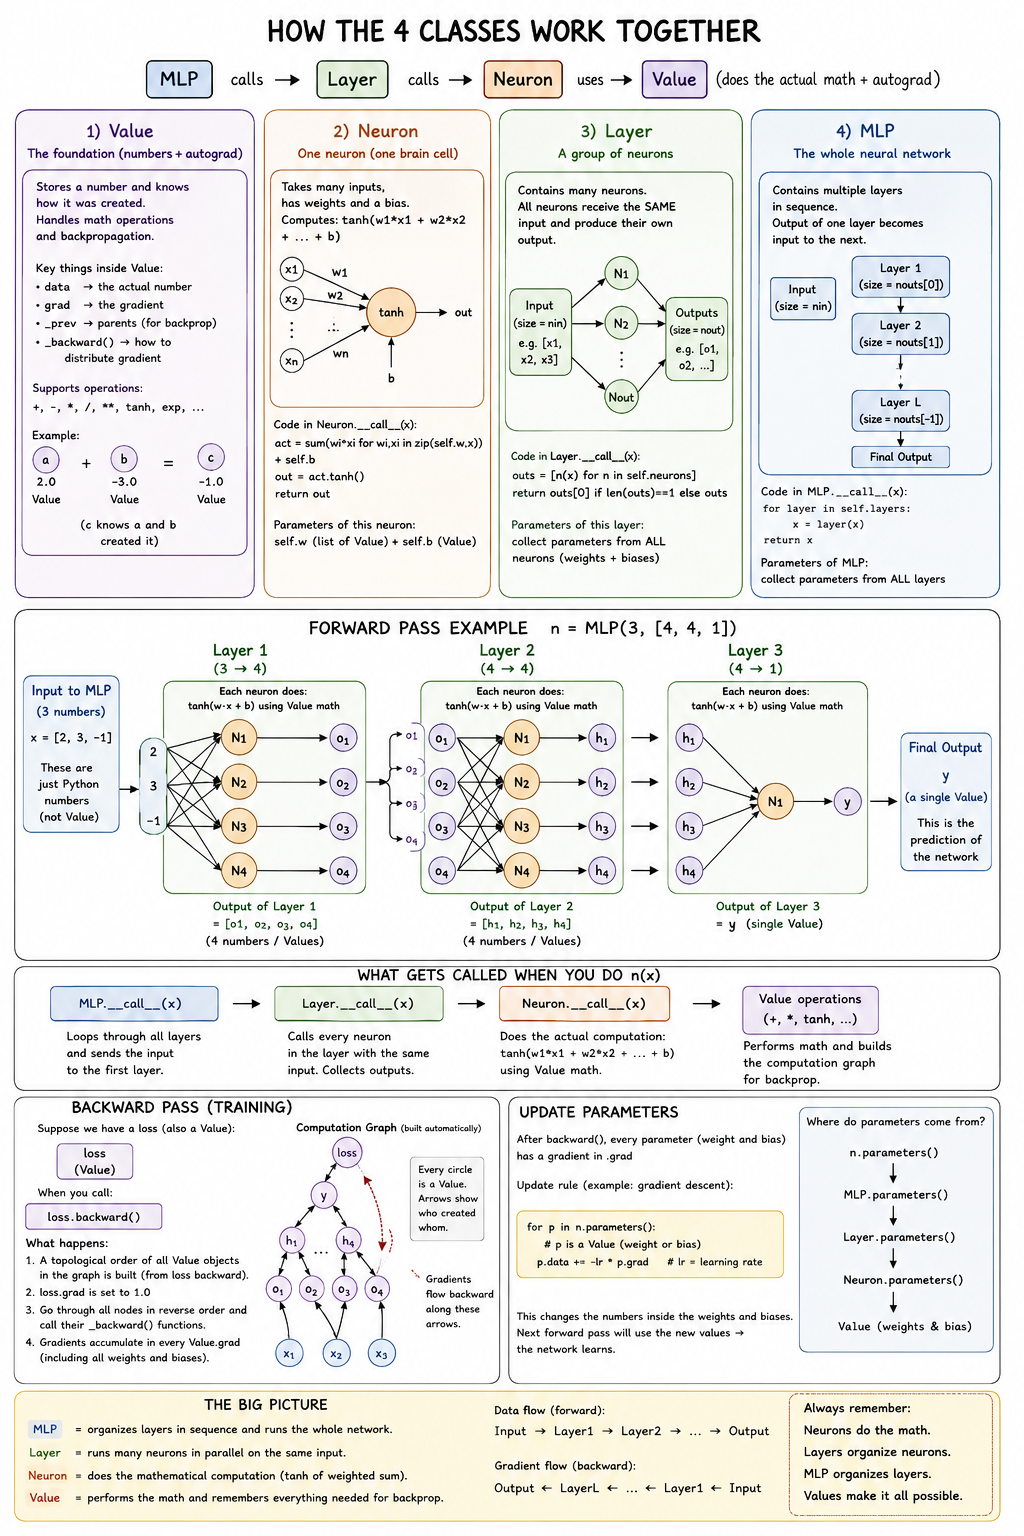